# 03. 손실과 학습

이번 노트북에서는 모델이 얼마나 틀렸는지 숫자로 계산해봅니다.

핵심 단어는 `loss`, 즉 손실입니다.

In [1]:
import numpy as np  # 숫자 배열과 평균 계산을 쉽게 하기 위한 라이브러리입니다.
import matplotlib.pyplot as plt  # 손실 변화를 그래프로 보기 위한 라이브러리입니다.

## 1. 정답과 예측 준비하기

아래는 어떤 모델이 만든 예측값이라고 생각해봅니다.

정답과 예측이 얼마나 다른지 계산해보겠습니다.

In [2]:
# 실제 정답입니다.
y_true = np.array([1, 3, 5, 7, 9], dtype=np.float32)

# 모델이 예측한 값입니다. 일부러 조금 틀리게 만들었습니다.
y_pred = np.array([0, 2, 6, 8, 10], dtype=np.float32)

print("정답:", y_true)
print("예측:", y_pred)

정답: [1. 3. 5. 7. 9.]
예측: [ 0.  2.  6.  8. 10.]


## 2. 오차 계산하기

오차는 정답과 예측의 차이다.

```text
오차 = 정답 - 예측
```

In [3]:
# 정답에서 예측을 빼면 오차가 됩니다.
errors = y_true - y_pred

print("오차:", errors)

오차: [ 1.  1. -1. -1. -1.]


## 3. 제곱 오차 계산하기

오차에는 양수와 음수가 섞일 수 있습니다.

그래서 회귀 문제에서는 오차를 제곱해서 양수로 만든 뒤 평균을 내는 MSE를 자주 사용합니다.

In [4]:
# 오차를 제곱합니다.
# ** 2는 제곱을 의미합니다.
squared_errors = errors ** 2

print("제곱 오차:", squared_errors)

제곱 오차: [1. 1. 1. 1. 1.]


## 4. MSE 계산하기

MSE는 Mean Squared Error의 줄임말입니다.

```text
오차 제곱들의 평균
```

In [5]:
# np.mean()은 평균을 계산하는 함수입니다.
mse = np.mean(squared_errors)

print("MSE:", mse)

MSE: 1.0


## 5. MSE 함수 만들기

앞으로 여러 예측값의 손실을 비교할 수 있도록 MSE 계산을 함수로 만들어봅니다.

In [6]:
def mean_squared_error(y_true, y_pred):
    # y_true: 실제 정답 배열입니다.
    # y_pred: 모델의 예측 배열입니다.
    # 두 배열의 차이를 제곱하고 평균을 내면 MSE가 됩니다.
    return np.mean((y_true - y_pred) ** 2)

## 6. 여러 예측 비교하기

어떤 예측이 더 좋은지 손실로 비교해봅니다.

손실이 낮을수록 더 좋은 예측입니다.

In [7]:
y_true = np.array([1, 3, 5, 7, 9], dtype=np.float32)

pred_bad = np.array([10, 10, 10, 10, 10], dtype=np.float32)
pred_mid = np.array([0, 2, 6, 8, 10], dtype=np.float32)
pred_good = np.array([1.1, 3.1, 4.9, 7.2, 8.8], dtype=np.float32)

print("나쁜 예측 MSE:", mean_squared_error(y_true, pred_bad))
print("중간 예측 MSE:", mean_squared_error(y_true, pred_mid))
print("좋은 예측 MSE:", mean_squared_error(y_true, pred_good))

나쁜 예측 MSE: 33.0
중간 예측 MSE: 1.0
좋은 예측 MSE: 0.021999963


## 7. w와 b 후보를 비교하기

이번에는 `y = wx + b`에서 여러 `w`, `b` 후보를 넣어보고 손실이 가장 작은 조합을 찾아봅니다.

이것은 진짜 딥러닝 학습은 아니지만, 모델이 좋은 내부 숫자를 찾아간다는 느낌을 잡는 데 도움이 됩니다.

In [8]:
x_data = np.array([0, 1, 2, 3, 4], dtype=np.float32)
y_true = np.array([1, 3, 5, 7, 9], dtype=np.float32)

def predict(x, w, b):
    # y = wx + b를 코드로 계산합니다.
    return w * x + b

candidates = [
    (0, 0),
    (1, 0),
    (2, 0),
    (2, 1),
    (3, 1),
]

for w, b in candidates:
    y_pred = predict(x_data, w, b)
    loss = mean_squared_error(y_true, y_pred)
    print(f"w={w}, b={b}, 예측={y_pred}, MSE={loss}")

w=0, b=0, 예측=[0. 0. 0. 0. 0.], MSE=33.0
w=1, b=0, 예측=[0. 1. 2. 3. 4.], MSE=11.0
w=2, b=0, 예측=[0. 2. 4. 6. 8.], MSE=1.0
w=2, b=1, 예측=[1. 3. 5. 7. 9.], MSE=0.0
w=3, b=1, 예측=[ 1.  4.  7. 10. 13.], MSE=6.0


## 8. 손실이 가장 작은 후보 찾기

위 후보 중에서는 `w=2`, `b=1`이 가장 좋습니다.

왜냐하면 정답 규칙이 `y = 2x + 1`이기 때문입니다.

딥러닝은 이런 좋은 값을 자동으로 찾아가도록 만든 방법입니다.

In [10]:
best_loss = None
best_w = None
best_b = None

# 여러 w와 b를 대충 탐색해봅니다.
# 실제 딥러닝은 이렇게 모든 후보를 다 찍어보는 방식보다 훨씬 효율적으로 값을 수정합니다.
for w in np.arange(-1, 4.1, 0.5):
    for b in np.arange(-1, 3.1, 0.5):
        y_pred = predict(x_data, w, b)
        loss = mean_squared_error(y_true, y_pred)

        if best_loss is None or loss < best_loss:
            best_loss = loss
            best_w = w
            best_b = b

print("가장 좋은 w:", best_w)
print("가장 좋은 b:", best_b)
print("가장 작은 MSE:", best_loss)

가장 좋은 w: 2.0
가장 좋은 b: 1.0
가장 작은 MSE: 0.0


## 9. 손실 그래프 느낌 보기

`b`를 1로 고정하고, `w`를 바꿔가며 손실이 어떻게 달라지는지 봅니다.

정답은 `w=2`, `b=1`이므로, `w=2` 근처에서 손실이 가장 낮아져야 합니다.

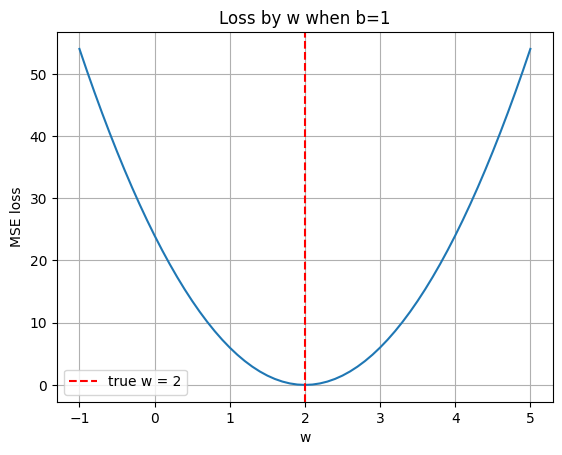

In [9]:
w_values = np.arange(-1, 5.1, 0.1)
loss_values = []

for w in w_values:
    y_pred = predict(x_data, w, b=1)
    loss = mean_squared_error(y_true, y_pred)
    loss_values.append(loss)

plt.plot(w_values, loss_values)
plt.axvline(2, color="red", linestyle="--", label="true w = 2")
plt.title("Loss by w when b=1")
plt.xlabel("w")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(True)
plt.show()

## 정리

이번 장의 핵심은 이것입니다.

```text
손실은 모델이 얼마나 틀렸는지 나타내는 숫자다.
학습은 손실을 줄이는 방향으로 모델 내부 숫자를 고치는 과정이다.
```

## 과제

1. 정답 `[2, 4, 6]`, 예측 `[1, 5, 7]`의 오차를 계산해보세요.
2. 위 오차의 제곱 오차와 MSE를 계산해보세요.
3. `y = 4x + 1` 데이터에서 가장 좋은 w와 b가 무엇인지 후보 탐색으로 찾아보세요.
4. 손실이 낮다는 것을 말로 설명해보세요.